# Market Dimensionality / Opportunity Set — Feasibility Test v0.3

## Objetivo desta versão

A v0.2 mostrou que, no universo bruto de 9 ETFs setoriais dos EUA, **Effective Rank (participation ratio), mean correlation e market mode ordenam os estados de mercado quase da mesma forma**.

A v0.3 faz duas coisas antes de tocar em alpha:

1. **audita matematicamente o Effective Rank**, deixando explícita sua redundância com correlações ao quadrado quando \(N\) é fixo;
2. testa se a estrutura continua essencialmente a mesma **depois de remover o fator de mercado (SPY)**.

> **Ainda não há backtest de estratégia nesta versão.**
> O objetivo é decidir se existe uma variável estrutural suficientemente defensável para justificar o próximo passo.

## Research question desta etapa

> Depois de retirar o movimento comum do mercado, sobra uma estrutura cross-sectional suficientemente distinta e estável para justificar a tese de *Opportunity Set*?

## Hipóteses

- **H1 — sanity estrutural:** o ER bruto mede concentração de co-movimento.
- **H2 — auditoria matemática:** o participation-ratio ER é uma transformação monotônica da correlação quadrática agregada para \(N\) fixo.
- **H3 — residualização:** retirar SPY deve reduzir o domínio do fator comum e pode revelar uma estrutura relativa diferente.
- **H4 — decisão:** só avançaremos para alpha se a estrutura residual acrescentar uma pergunta econômica útil.

## 0. Regras metodológicas congeladas

- Universo: `XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY`.
- Fator de mercado: `SPY`.
- Frequência: retornos diários; observação estrutural mensal.
- Janela-base: **252 pregões**.
- Nenhum dado posterior a \(t\) entra na estimativa em \(t\).
- OLS de mercado estimado dentro da própria janela histórica disponível em \(t\).
- Nenhum threshold de trading nesta versão.
- Nenhuma métrica será promovida porque “parece melhor” visualmente.

In [13]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError("Instale yfinance antes de rodar: pip install yfinance") from exc

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

SECTOR_TICKERS = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]
MARKET_TICKER = "SPY"
ALL_TICKERS = SECTOR_TICKERS + [MARKET_TICKER]

START = "2000-01-01"
END = None
WINDOW = 252
MIN_COVERAGE = 0.98

CACHE_FILE = DATA_DIR / "us_sector_etfs_plus_spy_adjusted_close.csv"

## 1. Dados

A v0.3 usa um novo cache porque agora precisamos também do SPY.

In [14]:
def load_prices(force_download: bool = False) -> pd.DataFrame:
    if CACHE_FILE.exists() and not force_download:
        return pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True).sort_index()

    raw = yf.download(
        ALL_TICKERS,
        start=START,
        end=END,
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True,
    )

    if raw.empty:
        raise RuntimeError("Download retornou vazio.")

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            prices = raw["Close"].copy()
        elif "Close" in raw.columns.get_level_values(1):
            prices = raw.xs("Close", axis=1, level=1).copy()
        else:
            raise KeyError("Coluna Close não encontrada.")
    else:
        prices = raw[["Close"]].rename(columns={"Close": ALL_TICKERS[0]})

    prices = prices.reindex(columns=ALL_TICKERS).sort_index()
    prices.to_csv(CACHE_FILE)
    return prices

prices = load_prices()

coverage = prices.notna().mean().sort_values()
display(coverage.to_frame("coverage"))

first_valid_dates = prices.apply(pd.Series.first_valid_index)
common_start = max(first_valid_dates)

px = prices.loc[common_start:].copy()
daily_coverage = px.notna().mean(axis=1)
px = px.loc[daily_coverage >= MIN_COVERAGE]
px = px.ffill(limit=3).dropna(how="any")

print("Common start:", common_start)
print("Observações:", len(px))
print("Início:", px.index.min())
print("Fim:", px.index.max())

assert set(ALL_TICKERS).issubset(px.columns)
assert not px.isna().any().any()

,coverage
XLB,1.0
XLE,1.0
XLF,1.0
XLI,1.0
XLK,1.0
XLP,1.0
XLU,1.0
XLV,1.0
XLY,1.0
SPY,1.0


Common start: 2000-01-03 00:00:00
Observações: 6690
Início: 2000-01-03 00:00:00
Fim: 2026-08-10 00:00:00


In [15]:
log_returns = np.log(px / px.shift(1)).dropna()

sector_returns = log_returns[SECTOR_TICKERS].copy()
market_returns = log_returns[MARKET_TICKER].copy()

display(sector_returns.describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
XLB,0.000299,0.014864,-0.132527,0.131533
XLE,0.000330,0.018204,-0.224910,0.152504
XLF,0.000247,0.017813,-0.182322,0.152394
XLI,0.000348,0.013367,-0.120408,0.119126
XLK,0.000329,0.016307,-0.148662,0.149296
XLP,0.000292,0.009433,-0.098668,0.081678
XLU,0.000308,0.012106,-0.120561,0.120388
XLV,0.000316,0.011207,-0.103818,0.113817
XLY,0.000355,0.014315,-0.135461,0.103351


# 2. Auditoria matemática do participation-ratio Effective Rank

Para uma matriz de correlação \(C\) com \(N\) ativos:

\[
ER =
\frac{(\sum_i \lambda_i)^2}
{\sum_i \lambda_i^2}
\]

Como \(\sum_i \lambda_i=N\) e

\[
\sum_i \lambda_i^2
=
\operatorname{tr}(C^2)
=
N + 2\sum_{i<j}\rho_{ij}^2,
\]

temos:

\[
ER =
\frac{N^2}
{N + 2\sum_{i<j}\rho_{ij}^2}.
\]

Se

\[
\overline{\rho^2}
=
\frac{2}{N(N-1)}
\sum_{i<j}\rho_{ij}^2,
\]

então:

\[
\boxed{
ER =
\frac{N}
{1+(N-1)\overline{\rho^2}}
}
\]

Portanto, para \(N\) fixo, esse ER é uma transformação monotônica da correlação quadrática agregada.

In [26]:
def structural_metrics_from_corr(corr: np.ndarray) -> dict[str, float]:
    n = corr.shape[0]

    eigvals = np.linalg.eigvalsh(corr)
    eigvals = np.clip(eigvals, 0.0, None)
    eigvals = np.sort(eigvals)[::-1]

    total = eigvals.sum()
    er = (total ** 2) / np.square(eigvals).sum()
    market_mode = eigvals[0] / total

    upper = corr[np.triu_indices(n, k=1)]
    mean_corr = np.mean(upper)
    mean_abs_corr = np.mean(np.abs(upper))
    mean_sq_corr = np.mean(np.square(upper))
    rms_corr = np.sqrt(mean_sq_corr)

    er_from_mean_sq = n / (1.0 + (n - 1.0) * mean_sq_corr)

    return {
        "effective_rank": float(er),
        "market_mode": float(market_mode),
        "mean_corr": float(mean_corr),
        "mean_abs_corr": float(mean_abs_corr),
        "mean_sq_corr": float(mean_sq_corr),
        "rms_corr": float(rms_corr),
        "er_from_mean_sq": float(er_from_mean_sq),
    }


# Exemplo mínimo para validar a função e gerar saída visível
example_corr = np.array(
    [
        [1.0, 0.60, 0.20],
        [0.60, 1.0, 0.10],
        [0.20, 0.10, 1.0],
    ]
)
example_metrics = structural_metrics_from_corr(example_corr)

display(pd.DataFrame([example_metrics], index=["example"]))

,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
example,2.356021,0.555929,0.3,0.3,0.136667,0.369685,2.356021


## 3. Estrutura bruta

O erro numérico entre `effective_rank` e `er_from_mean_sq` deve ser praticamente zero.

In [17]:
def rolling_raw_structure(sector_rets: pd.DataFrame, window: int = 252) -> pd.DataFrame:
    rows = []

    for end in range(window, len(sector_rets) + 1):
        w = sector_rets.iloc[end-window:end]
        corr = w.corr().to_numpy()

        metrics = structural_metrics_from_corr(corr)
        metrics["date"] = sector_rets.index[end - 1]
        rows.append(metrics)

    return pd.DataFrame(rows).set_index("date")

raw_structure_daily = rolling_raw_structure(sector_returns, WINDOW)

identity_error = (
    raw_structure_daily["effective_rank"]
    - raw_structure_daily["er_from_mean_sq"]
).abs()

print("Máximo erro absoluto da identidade ER:", identity_error.max())
display(raw_structure_daily.tail())

Máximo erro absoluto da identidade ER: 4.440892098500626e-15


,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
date,,,,,,,
2026-08-04,4.806795,0.364539,0.220243,0.278151,0.109044,0.330218,4.806795
2026-08-05,4.837398,0.362024,0.217297,0.276186,0.107563,0.327968,4.837398
2026-08-06,4.829381,0.362537,0.217250,0.276683,0.107949,0.328556,4.829381
2026-08-07,4.801365,0.364241,0.218682,0.278202,0.109308,0.330618,4.801365
2026-08-10,4.803874,0.364185,0.218878,0.277432,0.109186,0.330433,4.803874


# 4. Residualização point-in-time contra SPY

Para cada janela histórica terminando em \(t\), estimamos para cada setor:

\[
r_{i,\tau}
=
\alpha_{i,t}
+
\beta_{i,t}r_{SPY,\tau}
+
\epsilon_{i,\tau},
\qquad \tau \in [t-251,t].
\]

Depois usamos apenas os resíduos dessa janela histórica para construir a matriz de correlação residual.

Esta etapa **não assume** que residualização vai “salvar” o ER. Ela testa se o fator de mercado explica a redundância extrema observada nos retornos brutos.

In [18]:
def residualize_window_against_market(
    sector_window: pd.DataFrame,
    market_window: pd.Series,
) -> pd.DataFrame:
    # OLS univariado com intercepto, estimado separadamente por ativo.
    m = market_window.to_numpy(dtype=float)
    m_mean = m.mean()
    m_centered = m - m_mean
    var_m = np.dot(m_centered, m_centered)

    if var_m <= 0:
        raise ValueError("Variância do fator de mercado é zero.")

    residuals = pd.DataFrame(
        index=sector_window.index,
        columns=sector_window.columns,
        dtype=float,
    )

    for ticker in sector_window.columns:
        y = sector_window[ticker].to_numpy(dtype=float)
        y_mean = y.mean()
        y_centered = y - y_mean

        beta = np.dot(m_centered, y_centered) / var_m
        alpha = y_mean - beta * m_mean

        fitted = alpha + beta * m
        residuals[ticker] = y - fitted

    return residuals


def rolling_residual_structure(
    sector_rets: pd.DataFrame,
    market_rets: pd.Series,
    window: int = 252,
) -> pd.DataFrame:
    aligned = sector_rets.join(market_rets.rename("market"), how="inner").dropna()
    sectors = aligned[sector_rets.columns]
    market = aligned["market"]

    rows = []

    for end in range(window, len(aligned) + 1):
        sector_w = sectors.iloc[end-window:end]
        market_w = market.iloc[end-window:end]

        residuals = residualize_window_against_market(sector_w, market_w)
        corr_resid = residuals.corr().to_numpy()

        metrics = structural_metrics_from_corr(corr_resid)
        metrics["date"] = aligned.index[end - 1]
        rows.append(metrics)

    return pd.DataFrame(rows).set_index("date")


resid_structure_daily = rolling_residual_structure(
    sector_returns,
    market_returns,
    WINDOW,
)

display(resid_structure_daily.tail())

,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
date,,,,,,,
2026-08-04,5.288737,0.349099,0.058258,0.243426,0.087716,0.296169,5.288737
2026-08-05,5.292267,0.348797,0.057830,0.243137,0.087574,0.295930,5.292267
2026-08-06,5.283140,0.349314,0.058144,0.243484,0.087942,0.296549,5.283140
2026-08-07,5.264967,0.351003,0.058884,0.244514,0.088677,0.297786,5.264967
2026-08-10,5.265020,0.351297,0.058942,0.244902,0.088674,0.297782,5.265020


## 5. Amostragem mensal preservando a data real

In [19]:
def last_real_observation_each_month(df: pd.DataFrame) -> pd.DataFrame:
    month_key = df.index.to_period("M")
    return df.groupby(month_key, group_keys=False).tail(1).dropna()

raw_m = last_real_observation_each_month(raw_structure_daily)
resid_m = last_real_observation_each_month(resid_structure_daily)

print("RAW")
display(raw_m.tail())

print("RESIDUAL")
display(resid_m.tail())

RAW


,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
date,,,,,,,
2026-04-30,4.112024,0.430303,0.316612,0.325641,0.148588,0.385471,4.112024
2026-05-29,4.424013,0.406094,0.278013,0.304224,0.129294,0.359575,4.424013
2026-06-30,4.671094,0.381052,0.245629,0.282264,0.115843,0.340357,4.671094
2026-07-31,4.804108,0.364479,0.222832,0.276391,0.109175,0.330416,4.804108
2026-08-10,4.803874,0.364185,0.218878,0.277432,0.109186,0.330433,4.803874


RESIDUAL


,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
date,,,,,,,
2026-04-30,5.513484,0.341182,0.050304,0.229468,0.079045,0.281150,5.513484
2026-05-29,5.649467,0.333514,0.050199,0.227065,0.074134,0.272275,5.649467
2026-06-30,5.390133,0.347685,0.058447,0.241110,0.083715,0.289335,5.390133
2026-07-31,5.283897,0.349287,0.057918,0.243911,0.087911,0.296498,5.283897
2026-08-10,5.265020,0.351297,0.058942,0.244902,0.088674,0.297782,5.265020


# 6. Teste crítico: a residualização realmente muda a estrutura?

Comparamos Pearson e Spearman dentro das representações bruta e residual.

Se os descritores residuais continuarem quase perfeitamente redundantes, registramos isso; não inventamos uma narrativa.

In [20]:
cols = [
    "effective_rank",
    "mean_corr",
    "mean_abs_corr",
    "mean_sq_corr",
    "rms_corr",
    "market_mode",
]

print("RAW — Pearson")
display(raw_m[cols].corr(method="pearson"))

print("RAW — Spearman")
display(raw_m[cols].corr(method="spearman"))

print("RESIDUAL — Pearson")
display(resid_m[cols].corr(method="pearson"))

print("RESIDUAL — Spearman")
display(resid_m[cols].corr(method="spearman"))

RAW — Pearson


,effective_rank,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,market_mode
effective_rank,1.000000,-0.971046,-0.964287,-0.922781,-0.965225,-0.969422
mean_corr,-0.971046,1.000000,0.999263,0.984338,0.997251,0.998246
mean_abs_corr,-0.964287,0.999263,1.000000,0.988435,0.997936,0.998289
mean_sq_corr,-0.922781,0.984338,0.988435,1.000000,0.991283,0.988334
rms_corr,-0.965225,0.997251,0.997936,0.991283,1.000000,0.999506
market_mode,-0.969422,0.998246,0.998289,0.988334,0.999506,1.000000


RAW — Spearman


,effective_rank,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,market_mode
effective_rank,1.000000,-0.994578,-0.994654,-1.000000,-1.000000,-0.999478
mean_corr,-0.994578,1.000000,0.999979,0.994578,0.994578,0.996191
mean_abs_corr,-0.994654,0.999979,1.000000,0.994654,0.994654,0.996241
mean_sq_corr,-1.000000,0.994578,0.994654,1.000000,1.000000,0.999478
rms_corr,-1.000000,0.994578,0.994654,1.000000,1.000000,0.999478
market_mode,-0.999478,0.996191,0.996241,0.999478,0.999478,1.000000


RESIDUAL — Pearson


,effective_rank,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,market_mode
effective_rank,1.000000,-0.173586,-0.993140,-0.988489,-0.999277,-0.969999
mean_corr,-0.173586,1.000000,0.163552,0.224656,0.183729,0.349457
mean_abs_corr,-0.993140,0.163552,1.000000,0.979136,0.991753,0.959052
mean_sq_corr,-0.988489,0.224656,0.979136,1.000000,0.993251,0.970440
rms_corr,-0.999277,0.183729,0.991753,0.993251,1.000000,0.971445
market_mode,-0.969999,0.349457,0.959052,0.970440,0.971445,1.000000


RESIDUAL — Spearman


,effective_rank,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,market_mode
effective_rank,1.000000,-0.062797,-0.988016,-1.000000,-1.000000,-0.928742
mean_corr,-0.062797,1.000000,0.038800,0.062797,0.062797,0.265228
mean_abs_corr,-0.988016,0.038800,1.000000,0.988016,0.988016,0.903877
mean_sq_corr,-1.000000,0.062797,0.988016,1.000000,1.000000,0.928742
rms_corr,-1.000000,0.062797,0.988016,1.000000,1.000000,0.928742
market_mode,-0.928742,0.265228,0.903877,0.928742,0.928742,1.000000


In [21]:
comparison = pd.DataFrame({
    "raw_er": raw_m["effective_rank"],
    "resid_er": resid_m["effective_rank"],
    "raw_mean_corr": raw_m["mean_corr"],
    "resid_mean_corr": resid_m["mean_corr"],
    "raw_rms_corr": raw_m["rms_corr"],
    "resid_rms_corr": resid_m["rms_corr"],
    "raw_market_mode": raw_m["market_mode"],
    "resid_market_mode": resid_m["market_mode"],
}).dropna()

display(comparison.corr(method="pearson"))

,raw_er,resid_er,raw_mean_corr,resid_mean_corr,raw_rms_corr,resid_rms_corr,raw_market_mode,resid_market_mode
raw_er,1.000000,-0.259435,-0.971046,0.493710,-0.965225,0.255930,-0.969422,0.357022
resid_er,-0.259435,1.000000,0.253035,-0.173586,0.244389,-0.999277,0.261577,-0.969999
raw_mean_corr,-0.971046,0.253035,1.000000,-0.468446,0.997251,-0.249840,0.998246,-0.352913
resid_mean_corr,0.493710,-0.173586,-0.468446,1.000000,-0.503217,0.183729,-0.494778,0.349457
raw_rms_corr,-0.965225,0.244389,0.997251,-0.503217,1.000000,-0.242540,0.999506,-0.355413
resid_rms_corr,0.255930,-0.999277,-0.249840,0.183729,-0.242540,1.000000,-0.259508,0.971445
raw_market_mode,-0.969422,0.261577,0.998246,-0.494778,0.999506,-0.259508,1.000000,-0.368935
resid_market_mode,0.357022,-0.969999,-0.352913,0.349457,-0.355413,0.971445,-0.368935,1.000000


## 7. Visualização bruto vs residual

Padronização apenas para visualização; não será usada em nenhum sinal.

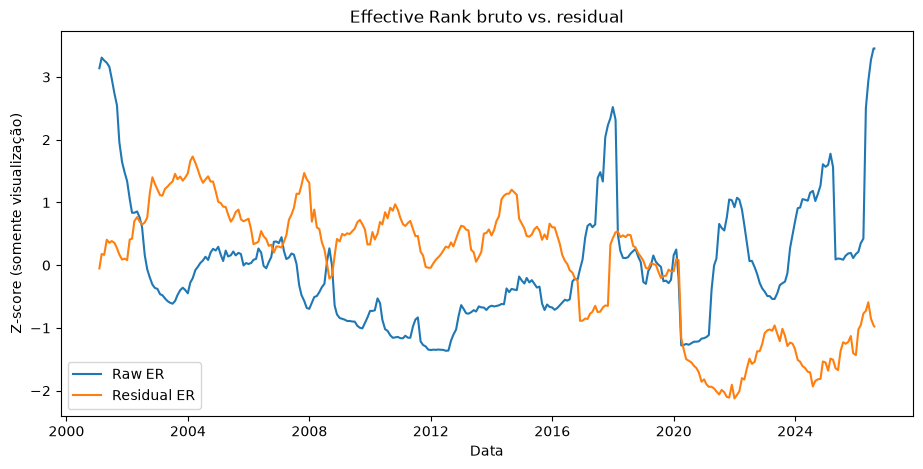

In [22]:
viz = (comparison - comparison.mean()) / comparison.std()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(viz.index, viz["raw_er"], label="Raw ER")
ax.plot(viz.index, viz["resid_er"], label="Residual ER")
ax.set_title("Effective Rank bruto vs. residual")
ax.set_xlabel("Data")
ax.set_ylabel("Z-score (somente visualização)")
ax.legend()
plt.show()

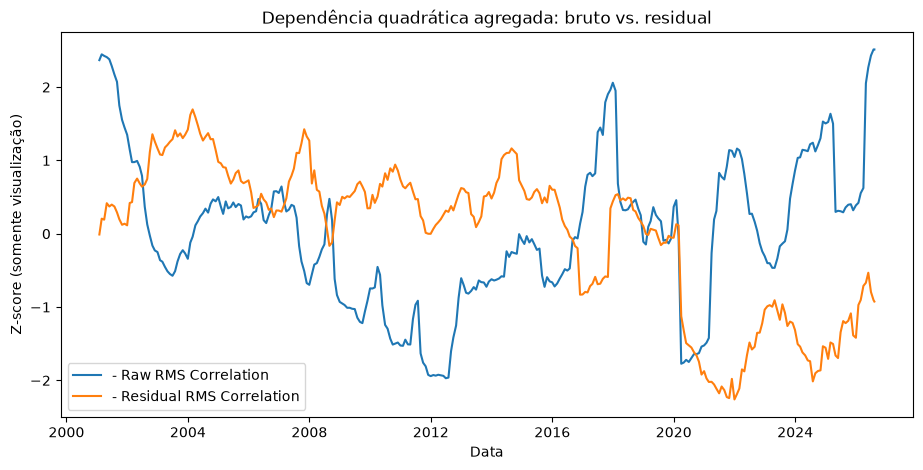

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(viz.index, -viz["raw_rms_corr"], label="- Raw RMS Correlation")
ax.plot(viz.index, -viz["resid_rms_corr"], label="- Residual RMS Correlation")
ax.set_title("Dependência quadrática agregada: bruto vs. residual")
ax.set_xlabel("Data")
ax.set_ylabel("Z-score (somente visualização)")
ax.legend()
plt.show()

## 8. Diagnóstico resumido

In [24]:
summary = pd.Series({
    "raw_ER_mean": raw_m["effective_rank"].mean(),
    "resid_ER_mean": resid_m["effective_rank"].mean(),

    "raw_mean_corr_mean": raw_m["mean_corr"].mean(),
    "resid_mean_corr_mean": resid_m["mean_corr"].mean(),

    "raw_rms_corr_mean": raw_m["rms_corr"].mean(),
    "resid_rms_corr_mean": resid_m["rms_corr"].mean(),

    "spearman_raw_ER_vs_meanCorr":
        raw_m["effective_rank"].corr(raw_m["mean_corr"], method="spearman"),

    "spearman_resid_ER_vs_meanCorr":
        resid_m["effective_rank"].corr(resid_m["mean_corr"], method="spearman"),

    "spearman_raw_ER_vs_RMS":
        raw_m["effective_rank"].corr(raw_m["rms_corr"], method="spearman"),

    "spearman_resid_ER_vs_RMS":
        resid_m["effective_rank"].corr(resid_m["rms_corr"], method="spearman"),

    "corr_rawER_vs_residER":
        comparison["raw_er"].corr(comparison["resid_er"]),

    "n_months": len(comparison),
})

display(summary)

raw_ER_mean                        2.283199
resid_ER_mean                      6.237347
raw_mean_corr_mean                 0.605150
resid_mean_corr_mean              -0.022310
raw_rms_corr_mean                  0.630141
resid_rms_corr_mean                0.237752
spearman_raw_ER_vs_meanCorr       -0.994578
spearman_resid_ER_vs_meanCorr     -0.062797
spearman_raw_ER_vs_RMS            -1.000000
spearman_resid_ER_vs_RMS          -1.000000
corr_rawER_vs_residER             -0.259435
n_months                         308.000000
dtype: float64

# PONTO DE DECISÃO — não avance automaticamente

Depois de executar a v0.3, precisamos escolher conscientemente entre:

## Caminho A — Opportunity Set simples
Se a estrutura residual for economicamente diferente, mas o participation-ratio ER continuar redundante com medidas simples, abandonamos o branding “Effective Rank” e usamos a medida mais simples defensável.

## Caminho B — ampliar a representação espectral
Podemos formular uma hipótese nova com uma medida que use mais da distribuição dos autovalores, por exemplo:

\[
p_i = \frac{\lambda_i}{\sum_j \lambda_j},
\qquad
ER_{entropy} =
\exp\left(-\sum_i p_i\ln p_i\right)
\]

Isso **não é equivalente** ao participation ratio, mas seria uma nova decisão metodológica e não poderá ser escolhida a posteriori apenas por performance.

## Caminho C — abandonar Market Dimensionality
Se residualização não produzir distinção economicamente útil e tudo continuar essencialmente uma medida de correlação, encerramos a tese antes de construir o alpha.

## O que não faremos nesta versão
Não adicionaremos Residual Momentum, thresholds ou carteira antes dessa decisão.

## Registro de decisões — v0.3

| Item | Estado |
|---|---|
| Tese central | Market Dimensionality / Opportunity Set |
| Participation-ratio ER bruto | válido, porém fortemente redundante |
| Identidade ER ↔ mean squared correlation | auditada explicitamente |
| Fator comum | SPY |
| Residualização | rolling OLS point-in-time, 252 dias |
| Estrutura residual | **A TESTAR AO EXECUTAR** |
| Alpha | **NÃO IMPLEMENTADO** |
| OOS de alpha | **NÃO DEFINIDO AINDA** |
| Próxima decisão | Caminho A, B ou C |